In [2]:
import os
import numpy as np
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import matplotlib.gridspec as gridspec
from skimage.metrics import structural_similarity as ssim
import cv2
from collections import defaultdict

/Users/fionamagee/Documents/GitHub/eclipse/Project3---AIvsReal-Image-Classification/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from datasets import load_dataset
from PIL import Image

In [12]:
BATCH_SIZE = 32
EPOCHS = 5
LR = 1e-4
NUM_SAMPLES_PER_CLASS = 2500  # 2500 real + 2500 AI = 5000 total, perfectly balanced
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {DEVICE}")

Using: cpu


Streaming until 2500 real + 2500 AI images collected...
  Real: 84 | AI: 416
  Real: 167 | AI: 833
  Real: 250 | AI: 1250
  Real: 334 | AI: 1666
  Real: 417 | AI: 2083
  Real: 500 | AI: 2500
  Real: 1000 | AI: 2500
  Real: 1000 | AI: 2500
  Real: 1000 | AI: 2500
  Real: 1000 | AI: 2500
  Real: 1000 | AI: 2500
  Real: 1000 | AI: 2500
  Real: 1500 | AI: 2500
  Real: 1500 | AI: 2500
  Real: 1500 | AI: 2500
  Real: 1500 | AI: 2500
  Real: 1500 | AI: 2500
  Real: 1500 | AI: 2500
  Real: 2000 | AI: 2500
  Real: 2000 | AI: 2500
  Real: 2000 | AI: 2500
  Real: 2000 | AI: 2500
  Real: 2000 | AI: 2500
  Real: 2000 | AI: 2500
  Real: 2500 | AI: 2500

Done! Real: 2500 | AI: 2500 | Total: 5000


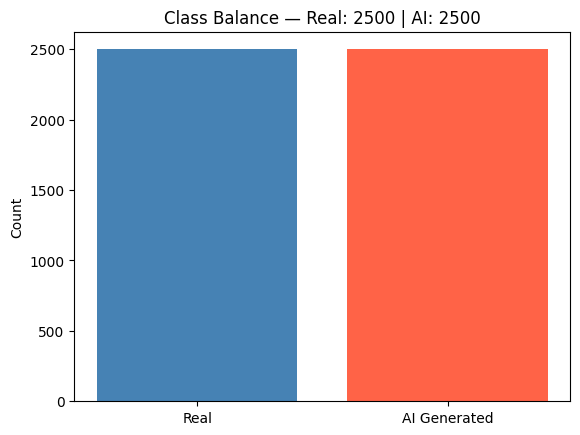

In [13]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

class DefactifyDataset(Dataset):
    def __init__(self, num_samples_per_class, transform):
        raw = load_dataset(
            "Rajarshi-Roy-research/Defactify_Image_Dataset",
            split="train",
            streaming=True
        )
        self.data = []
        real_count, ai_count = 0, 0
        target = num_samples_per_class

        print(f"Streaming until {target} real + {target} AI images collected...")
        for row in raw:
            if real_count >= target and ai_count >= target:
                break

            label = row["Label_A"]

            if label == 0 and real_count < target:
                img = row["Image"].convert("RGB")
                self.data.append((transform(img), torch.tensor(0)))
                real_count += 1

            elif label == 1 and ai_count < target:
                img = row["Image"].convert("RGB")
                self.data.append((transform(img), torch.tensor(1)))
                ai_count += 1

            if (real_count + ai_count) % 500 == 0:
                print(f"  Real: {real_count} | AI: {ai_count}")

        print(f"\nDone! Real: {real_count} | AI: {ai_count} | Total: {len(self.data)}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


# ── Build dataset & split 80/20 ────────────────────────────
dataset = DefactifyDataset(NUM_SAMPLES_PER_CLASS, transform)

train_size = int(0.8 * len(dataset))
val_size   = len(dataset) - train_size
train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)

# ── Verify balance visually ────────────────────────────────
labels = [dataset[i][1].item() for i in range(len(dataset))]
plt.bar(["Real", "AI Generated"], [labels.count(0), labels.count(1)],
        color=["steelblue", "tomato"])
plt.title(f"Class Balance — Real: {labels.count(0)} | AI: {labels.count(1)}")
plt.ylabel("Count")
plt.show()

In [14]:
def train_model(model, train_loader, val_loader, epochs, label):
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()
    history = {"train_acc": [], "val_acc": [], "loss": []}

    for epoch in range(epochs):
        # -- train --
        model.train()
        total_loss, correct = 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            correct += (out.argmax(1) == labels).sum().item()

        # -- val --
        model.eval()
        val_correct = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                val_correct += (model(imgs).argmax(1) == labels).sum().item()

        t_acc = correct / len(train_ds)
        v_acc = val_correct / len(val_ds)
        history["train_acc"].append(t_acc)
        history["val_acc"].append(v_acc)
        history["loss"].append(total_loss)
        print(f"[{label}] Epoch {epoch+1}/{epochs} | Loss: {total_loss:.2f} | Train: {t_acc:.2%} | Val: {v_acc:.2%}")

    return history

In [ ]:
class CustomCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 224 → 112

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 112 → 56

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 56 → 28
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


cnn_model = CustomCNN().to(DEVICE)
print(f"Custom CNN parameters: {sum(p.numel() for p in cnn_model.parameters()):,}")

cnn_history = train_model(cnn_model, train_loader, val_loader, EPOCHS, "CustomCNN")
torch.save(cnn_model.state_dict(), "custom_cnn.pth")

In [ ]:
efficientnet = models.efficientnet_b0(weights="IMAGENET1K_V1")
efficientnet.classifier[1] = nn.Linear(
    efficientnet.classifier[1].in_features, 2
)
efficientnet = efficientnet.to(DEVICE)

print(f"EfficientNet parameters: {sum(p.numel() for p in efficientnet.parameters()):,}")

eff_history = train_model(efficientnet, train_loader, val_loader, EPOCHS, "EfficientNet")
torch.save(efficientnet.state_dict(), "efficientnet.pth")